In [40]:
from __future__ import annotations

import copy
import math
import unittest
from collections import defaultdict
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

import numpy as np


from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

## Задание 1.

In [35]:
class BaseNetwork(nn.Module):
    def __init__(
        self,
        act_fn,
        input_size=784,
        num_classes=10,
        hidden_sizes=(512, 256, 256, 128)
    ):
        super().__init__()

        modules = []
        sizes = [input_size, *hidden_sizes]

        for n_in, n_out in zip(sizes[:-1], sizes[1:]):
            modules.append(nn.Linear(n_in, n_out))
            modules.append(copy.deepcopy(act_fn))

        modules.append(nn.Linear(sizes[-1], num_classes))
        self.layers = nn.ModuleList(modules)
        self.config = {
            "act_fn": act_fn.__class__.__name__,
            "input_size": input_size,
            "num_classes": num_classes,
            "hidden_sizes": list(hidden_sizes),
        }

        self.activations = []
        self.layer_grad_norms = defaultdict(list)
        linear_idx = 0

        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                layer.weight.register_hook(
                    self._make_gradient_hook(linear_idx)
                )
                linear_idx += 1

    def _make_gradient_hook(self, layer_idx):
        def hook(grad):
            self.layer_grad_norms[layer_idx].append(
                grad.detach().norm().item()
            )
        return hook

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        self.activations = []
        for layer in self.layers:
            x = layer(x)
            if isinstance(
                layer,
                (nn.ReLU, nn.Tanh, nn.Identity, nn.GELU)
            ):
                self.activations.append(x.detach())

        return x

In [36]:
def initialize(model, scheme):
    for layer in model.modules():

        if not isinstance(layer, nn.Linear):
            continue

        if scheme == "constant":
            nn.init.constant_(layer.weight, 0.02)

        elif scheme == "normal":
            nn.init.normal_(
                layer.weight,
                mean=0.0,
                std=0.05
            )

        elif scheme == "xavier":
            nn.init.xavier_uniform_(layer.weight)

        elif scheme == "kaiming":
            nn.init.kaiming_uniform_(
                layer.weight,
                nonlinearity="relu"
            )

        else:
            raise ValueError(
                f"Unknown initialization: {scheme}"
            )

        nn.init.zeros_(layer.bias)

In [37]:
def evaluate(model, loader, device):
    model.eval()
    loss_sum = 0.0
    correct = 0
    count = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = nn.functional.cross_entropy(logits, y, reduction="sum")
            loss_sum += loss.item()
            correct += (logits.argmax(dim=1) == y).sum().item()
            count += y.numel()
    return (loss_sum / count, correct / count)

In [52]:
def run_experiments(epochs=5, batch_size=128, limit_train=12000, seed=17):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    transform = transforms.ToTensor()
    train_set = datasets.FashionMNIST("data", train=True, download=True, transform=transform)
    test_set = datasets.FashionMNIST("data", train=False, download=True, transform=transform)
    if limit_train is not None:
        train_set = torch.utils.data.Subset(train_set, range(limit_train))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    activations = {"ReLU": nn.ReLU(), "tanh": nn.Tanh(), "identity": nn.Identity(), "GELU": nn.GELU()}
    schemes = ("constant", "normal", "xavier", "kaiming")
    NUM_LINEAR_LAYERS = 5
    NUM_ACTIVATION_LAYERS = 4
    results = {}
    for act_name, act_fn in activations.items():
        for scheme in schemes:
            print("\n" + "=" * 70)
            print(f"Activation: {act_name} | Initialization: {scheme}")
            print("=" * 70)
            torch.manual_seed(seed)
            np.random.seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            model = BaseNetwork(act_fn=act_fn).to(device)
            initialize(model, scheme)
            optimizer = torch.optim.SGD(model.parameters(), lr=0.03, momentum=0.9)
            history = {"train_loss": [], "test_loss": [], "test_accuracy": [], "activation_std": [], "gradient_norm": [], "diverged": False}
            for epoch in range(epochs):
                model.train()
                total_loss = 0.0
                seen = 0
                epoch_gradient_values = defaultdict(list)
                diverged = False
                for x, y in train_loader:
                    x = x.to(device)
                    y = y.to(device)
                    optimizer.zero_grad(set_to_none=True)
                    logits = model(x)
                    loss = nn.functional.cross_entropy(logits, y)
                    if not torch.isfinite(loss):
                        print(f"WARNING: non-finite loss at epoch {epoch + 1}. Experiment diverged.")
                        diverged = True
                        break
                    loss.backward()
                    bad_gradient = False
                    for layer_idx, values in model.layer_grad_norms.items():
                        for value in values:
                            if not np.isfinite(value):
                                bad_gradient = True
                                break
                            epoch_gradient_values[layer_idx].append(value)
                        if bad_gradient:
                            break
                    model.layer_grad_norms.clear()
                    if bad_gradient:
                        print(f"WARNING: non-finite gradient at epoch {epoch + 1}. Experiment diverged.")
                        diverged = True
                        break
                    optimizer.step()
                    bad_parameters = False
                    for parameter in model.parameters():
                        if not torch.isfinite(parameter).all():
                            bad_parameters = True
                            break
                    if bad_parameters:
                        print(f"WARNING: non-finite parameter at epoch {epoch + 1}. Experiment diverged.")
                        diverged = True
                        break
                    total_loss += loss.item() * y.numel()
                    seen += y.numel()
                if diverged:
                    history["diverged"] = True
                    history["train_loss"].append(np.nan)
                    history["test_loss"].append(np.nan)
                    history["test_accuracy"].append(np.nan)
                    history["activation_std"].append([np.nan] * NUM_ACTIVATION_LAYERS)
                    history["gradient_norm"].append([np.nan] * NUM_LINEAR_LAYERS)
                    break
                train_loss = total_loss / seen if seen > 0 else np.nan
                history["train_loss"].append(train_loss)
                epoch_gradient_norm = []
                for layer_idx in range(NUM_LINEAR_LAYERS):
                    values = epoch_gradient_values[layer_idx]
                    if len(values) == 0:
                        epoch_gradient_norm.append(np.nan)
                    else:
                        mean_gradient = np.mean(values)
                        epoch_gradient_norm.append(float(mean_gradient) if np.isfinite(mean_gradient) else np.nan)
                history["gradient_norm"].append(epoch_gradient_norm)
                test_loss, test_accuracy = evaluate(model, test_loader, device)
                if not np.isfinite(test_loss):
                    print(f"WARNING: non-finite test loss at epoch {epoch + 1}. Experiment diverged.")
                    history["diverged"] = True
                    history["test_loss"].append(np.nan)
                    history["test_accuracy"].append(np.nan)
                    history["activation_std"].append([np.nan] * NUM_ACTIVATION_LAYERS)
                    break
                history["test_loss"].append(test_loss)
                history["test_accuracy"].append(test_accuracy)
                model.eval()
                activation_values = []
                with torch.no_grad():
                    x_eval, _ = next(iter(test_loader))
                    x_eval = x_eval.to(device)
                    model(x_eval)
                    for activation in model.activations:
                        value = activation.std().item()
                        activation_values.append(value if np.isfinite(value) else np.nan)
                history["activation_std"].append(activation_values)
                print(f"Epoch {epoch + 1:2d}/{epochs} | train loss = {train_loss:.4f} | test loss = {test_loss:.4f} | test acc = {test_accuracy:.4f}")
            results[(act_name, scheme)] = history
    return results

In [53]:
fashion_results = run_experiments(
    epochs=5,
    batch_size=128,
    limit_train=12000,
    seed=17
)

Device: cpu

Activation: ReLU | Initialization: constant
Epoch  1/5 | train loss = 1906.8583 | test loss = 2.3032 | test acc = 0.1000
Epoch  2/5 | train loss = 2.3028 | test loss = 2.3031 | test acc = 0.1000
Epoch  3/5 | train loss = 2.3031 | test loss = 2.3031 | test acc = 0.1000
Epoch  4/5 | train loss = 2.3030 | test loss = 2.3035 | test acc = 0.1000
Epoch  5/5 | train loss = 2.3032 | test loss = 2.3031 | test acc = 0.1000

Activation: ReLU | Initialization: normal
Epoch  1/5 | train loss = 1.1968 | test loss = 0.6636 | test acc = 0.7376
Epoch  2/5 | train loss = 0.5462 | test loss = 0.5561 | test acc = 0.7988
Epoch  3/5 | train loss = 0.4642 | test loss = 0.5940 | test acc = 0.7772
Epoch  4/5 | train loss = 0.4312 | test loss = 0.5548 | test acc = 0.8039
Epoch  5/5 | train loss = 0.3796 | test loss = 0.4645 | test acc = 0.8337

Activation: ReLU | Initialization: xavier
Epoch  1/5 | train loss = 0.9575 | test loss = 0.6437 | test acc = 0.7563
Epoch  2/5 | train loss = 0.5091 | test 

In [54]:
def plot_convergence(results):
    activations = sorted(set(name[0] for name in results.keys()))
    schemes = ["constant", "normal", "xavier", "kaiming"]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    for ax, act_name in zip(axes, activations):
        for scheme in schemes:
            key = (act_name, scheme)
            if key not in results:
                continue
            h = results[key]
            epochs = np.arange(1, len(h["train_loss"]) + 1)
            train_loss = np.asarray(h["train_loss"], dtype=float)
            test_accuracy = np.asarray(h["test_accuracy"], dtype=float)
            ax.plot(epochs, train_loss, marker="o", label=f"{scheme} loss")
        ax.set_title(f"{act_name}: training convergence")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Train loss")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    fig.suptitle("FashionMNIST — Training loss", fontsize=16)
    fig.tight_layout()
    plt.show()
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    for ax, act_name in zip(axes, activations):
        for scheme in schemes:
            key = (act_name, scheme)
            if key not in results:
                continue
            h = results[key]
            epochs = np.arange(1, len(h["test_accuracy"]) + 1)
            accuracy = np.asarray(h["test_accuracy"], dtype=float)
            ax.plot(epochs, accuracy * 100, marker="o", label=scheme)
        ax.set_title(f"{act_name}: test accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy (%)")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    fig.suptitle("FashionMNIST — Test accuracy", fontsize=16)
    fig.tight_layout()
    plt.show()

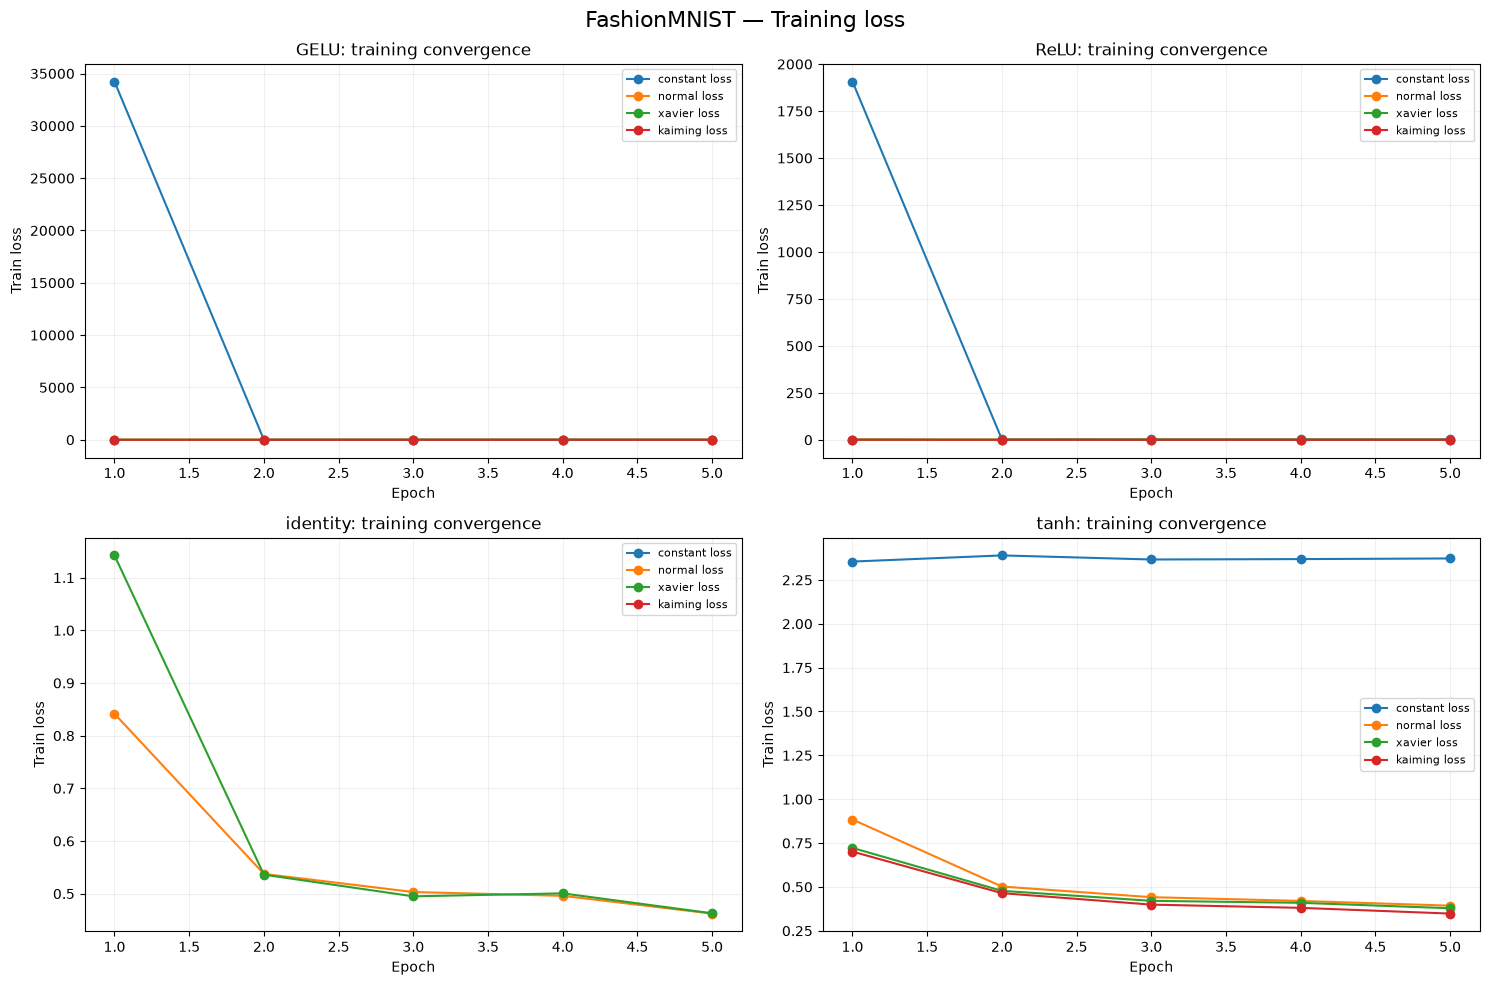

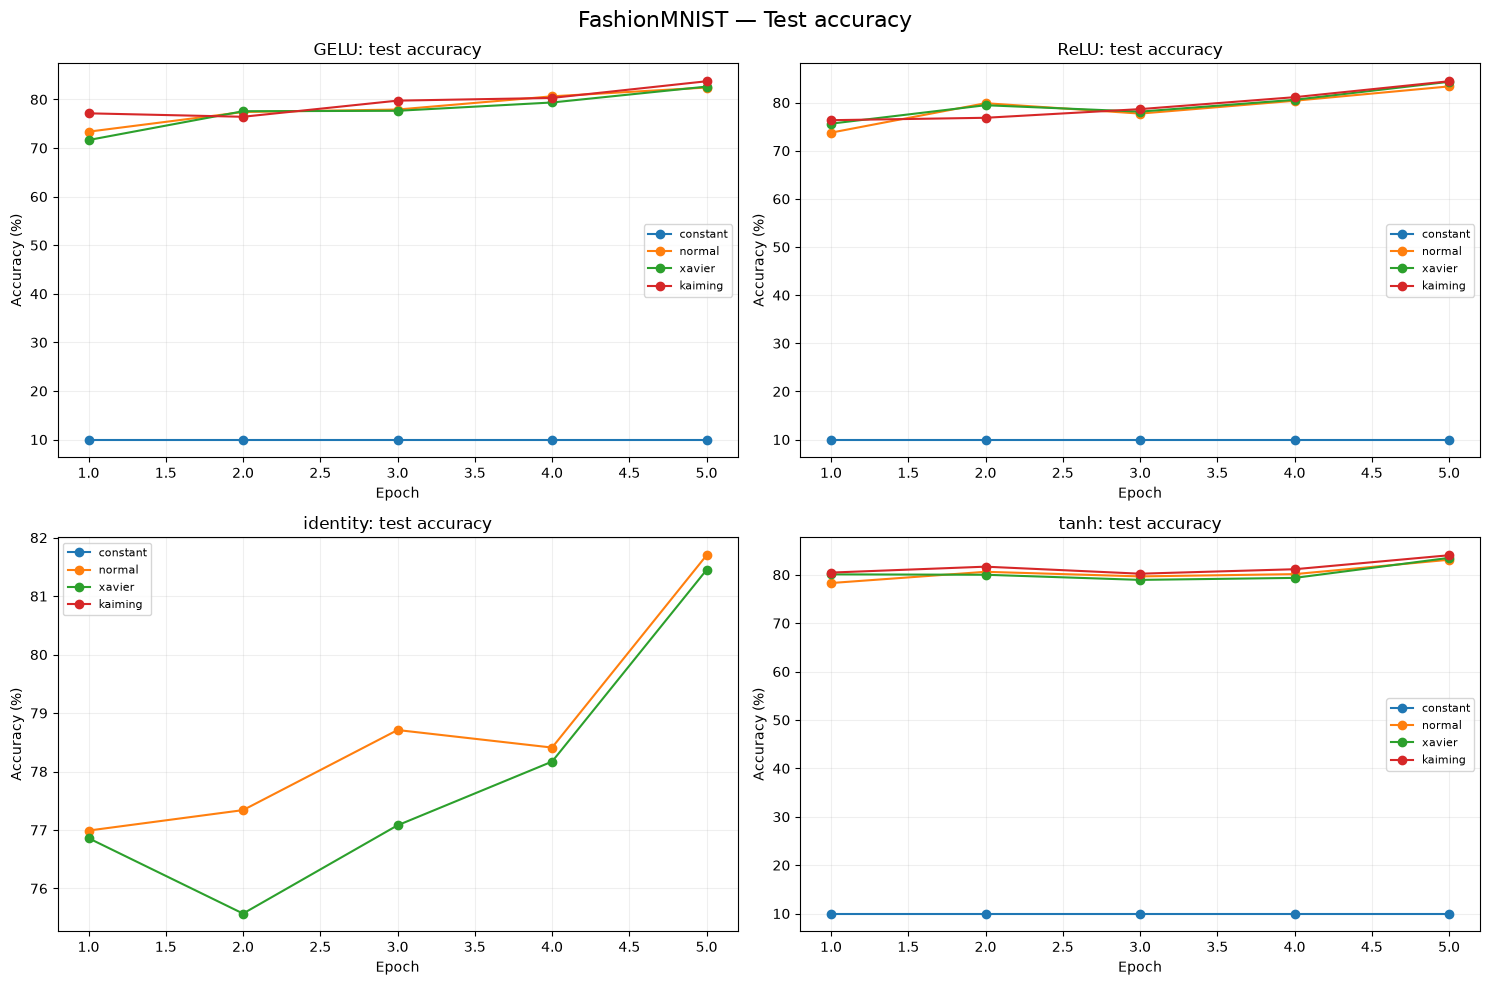

In [55]:
plot_convergence(fashion_results)

In [56]:
def plot_activation_dynamics(results):
    activations = ["ReLU", "tanh", "identity", "GELU"]
    schemes = ["constant", "normal", "xavier", "kaiming"]
    layer_names = ["Hidden layer 1", "Hidden layer 2", "Hidden layer 3", "Hidden layer 4"]
    for act_name in activations:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        for ax, scheme in zip(axes, schemes):
            key = (act_name, scheme)
            if key not in results:
                continue
            h = results[key]
            activation_std = np.asarray(h["activation_std"], dtype=float)
            epochs = np.arange(1, activation_std.shape[0] + 1)
            for layer_idx in range(activation_std.shape[1]):
                ax.plot(epochs, activation_std[:, layer_idx], marker="o", label=layer_names[layer_idx])
            ax.set_title(f"{act_name} + {scheme}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Activation standard deviation")
            ax.grid(alpha=0.2)
            ax.legend(fontsize=8)
        fig.suptitle(f"{act_name}: activation stability by layer", fontsize=16)
        fig.tight_layout()
        plt.show()

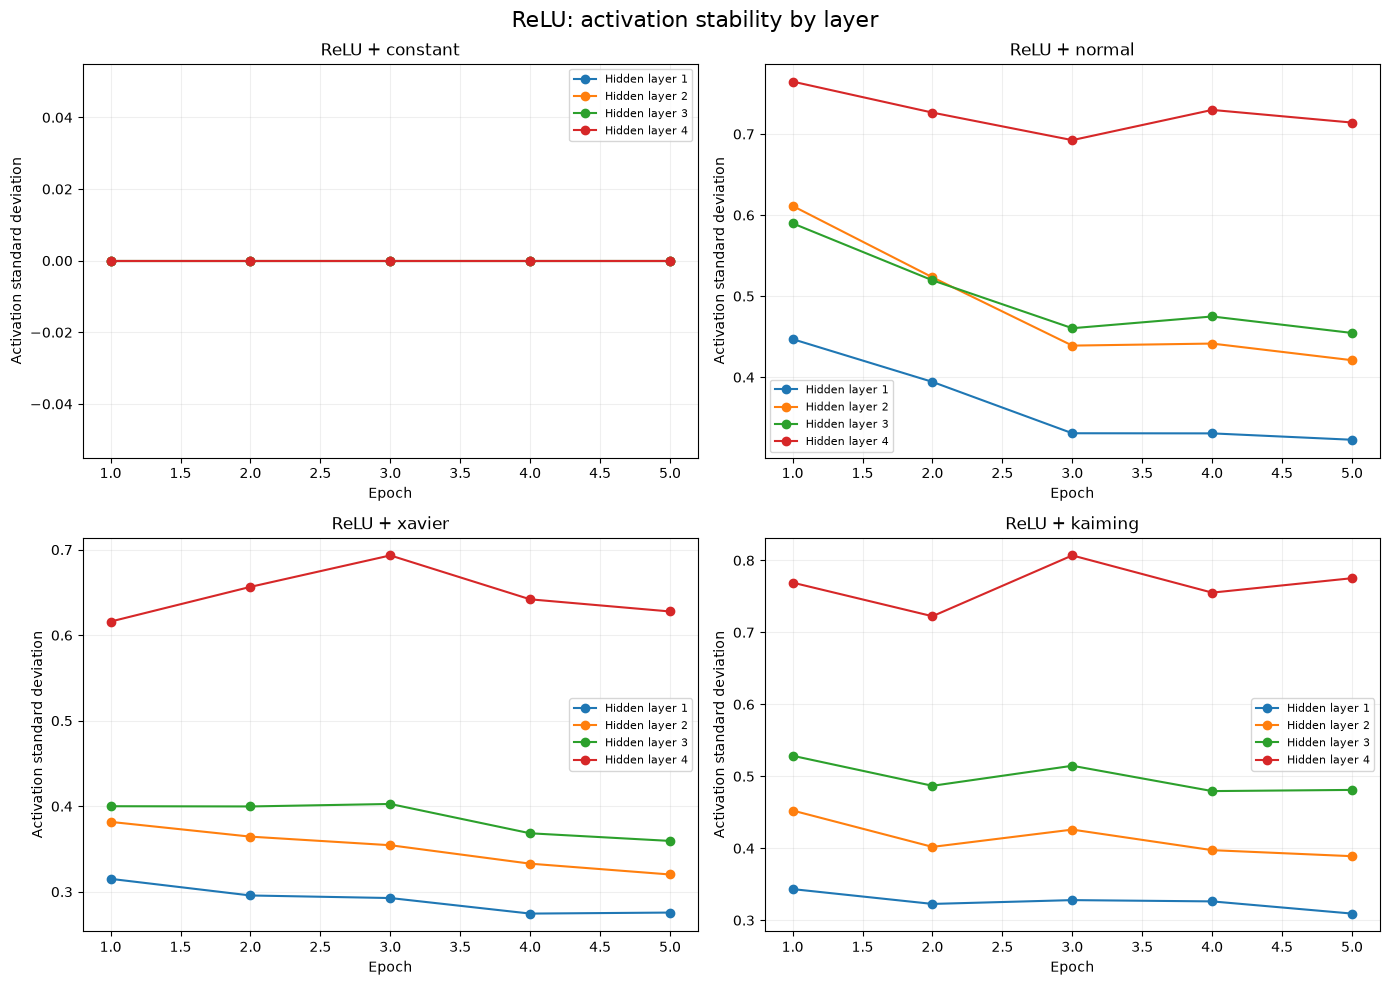

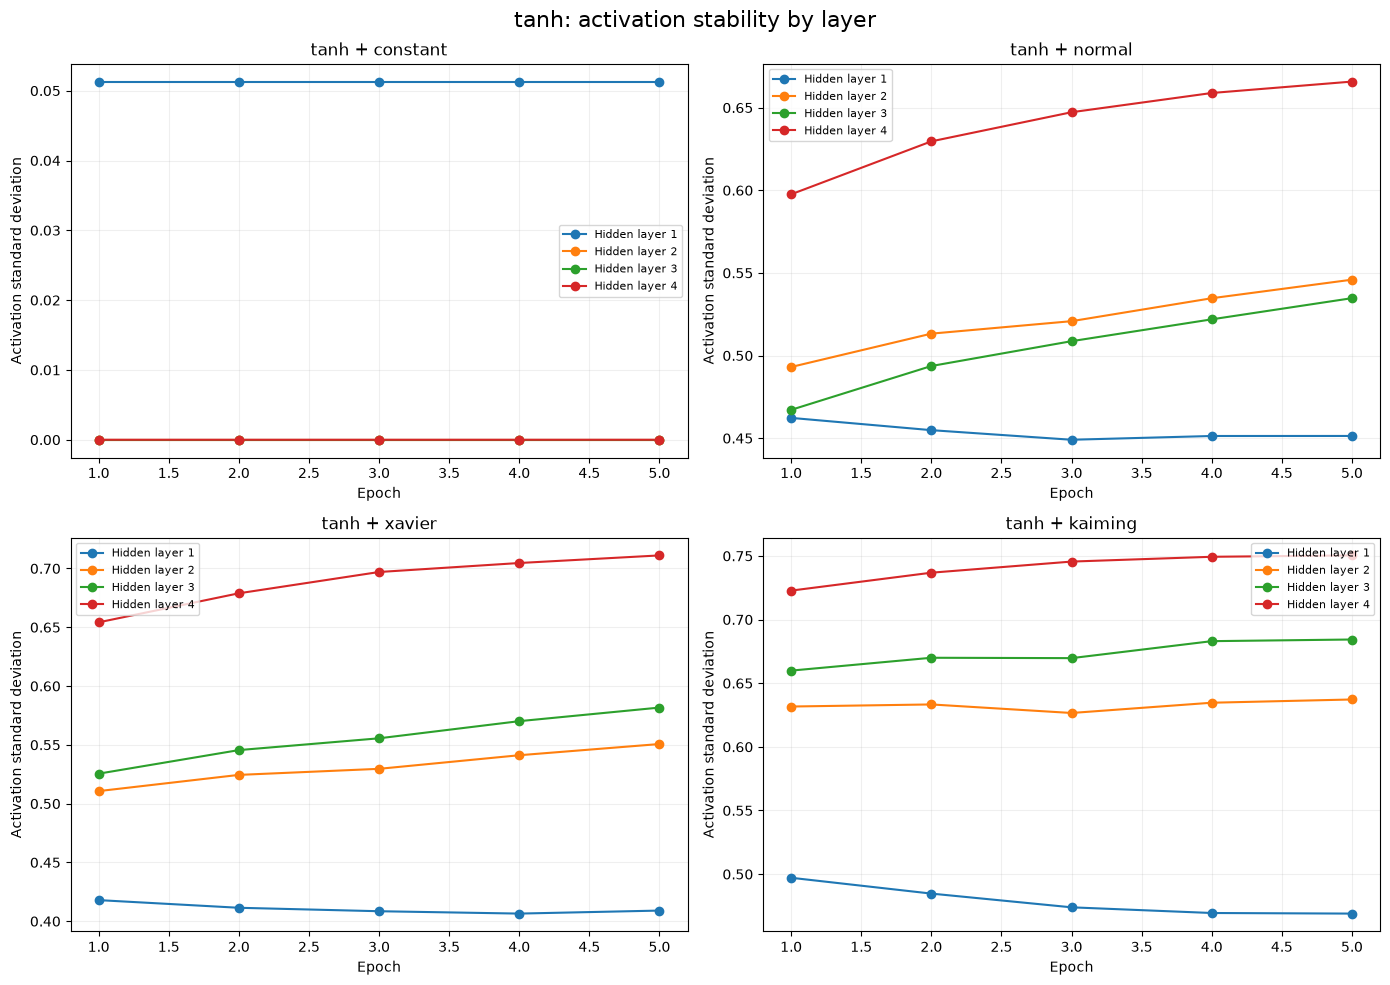

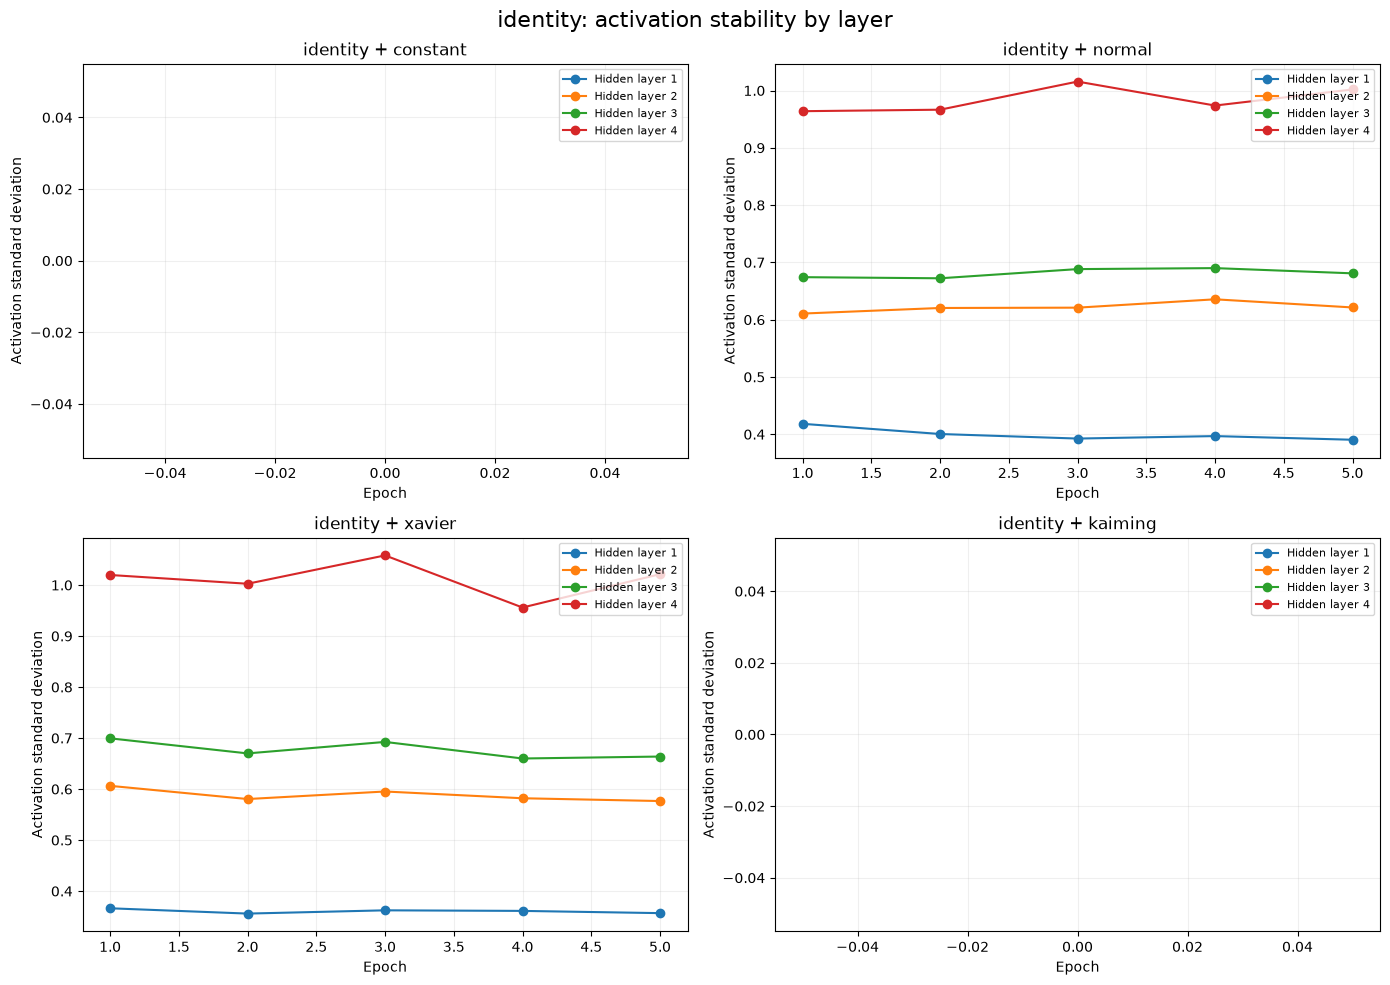

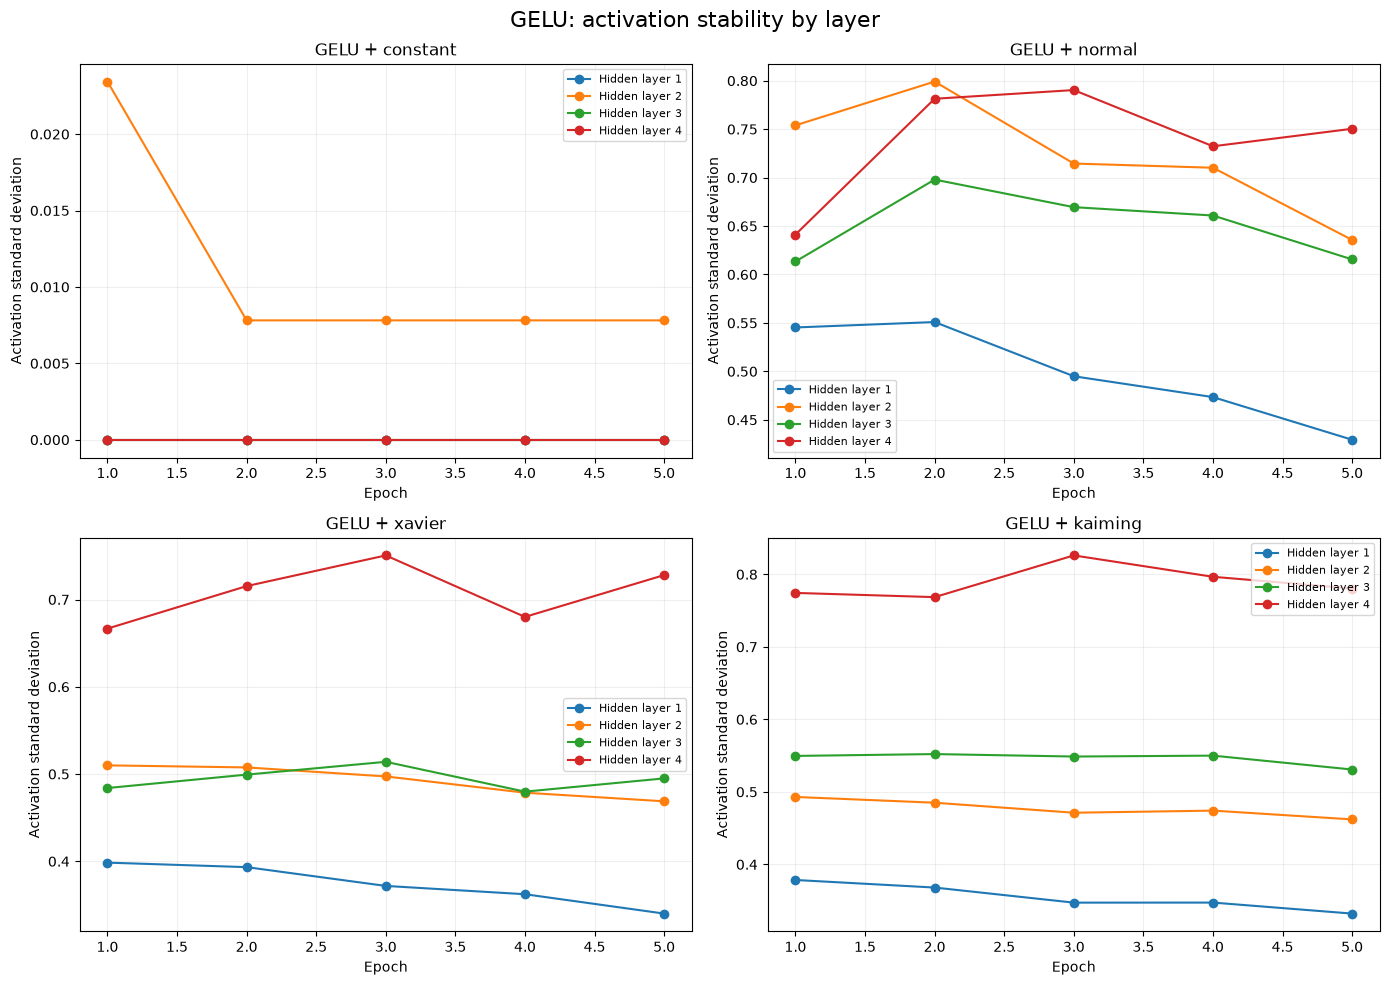

In [57]:
plot_activation_dynamics(
    fashion_results
)

In [61]:
def plot_final_layer_statistics(results):
    activations = ["ReLU", "tanh", "identity", "GELU"]
    schemes = ["constant", "normal", "xavier", "kaiming"]
    for act_name in activations:
        plt.figure(figsize=(10, 6))
        for scheme in schemes:
            key = (act_name, scheme)
            if key not in results:
                continue
            h = results[key]
            values = np.asarray(h["activation_std"][-1], dtype=float)
            plt.plot(range(1, len(values) + 1), values, marker="o", label=scheme)
        plt.title(f"{act_name}: final activation std by layer")
        plt.xlabel("Hidden layer")
        plt.ylabel("Activation standard deviation")
        plt.xticks([1, 2, 3, 4])
        plt.grid(alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()
    for act_name in activations:
        plt.figure(figsize=(10, 6))
        for scheme in schemes:
            key = (act_name, scheme)
            if key not in results:
                continue
            h = results[key]
            values = np.asarray(h["gradient_norm"][-1], dtype=float)
            plt.plot(range(1, len(values) + 1), values, marker="o", label=scheme)
        plt.title(f"{act_name}: final gradient norm by layer")
        plt.xlabel("Linear layer")
        plt.ylabel("Gradient L2 norm")
        plt.yscale("log")
        plt.xticks([1, 2, 3, 4])
        plt.grid(alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()

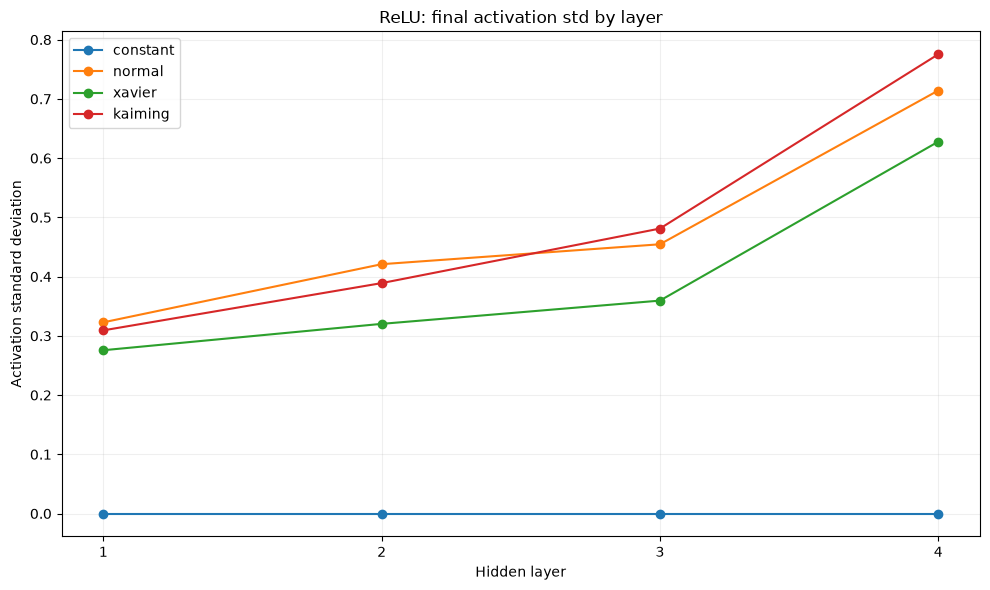

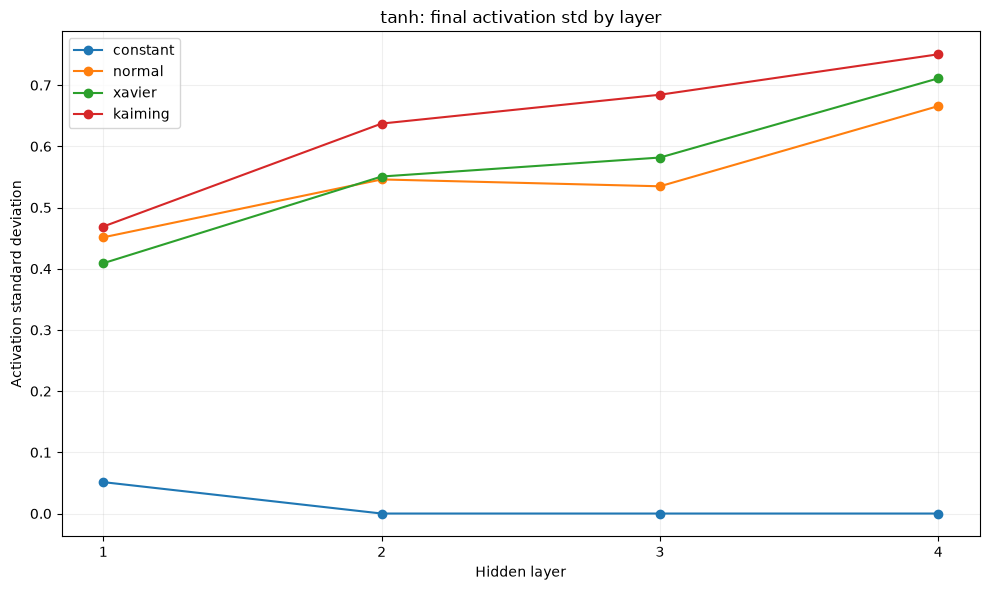

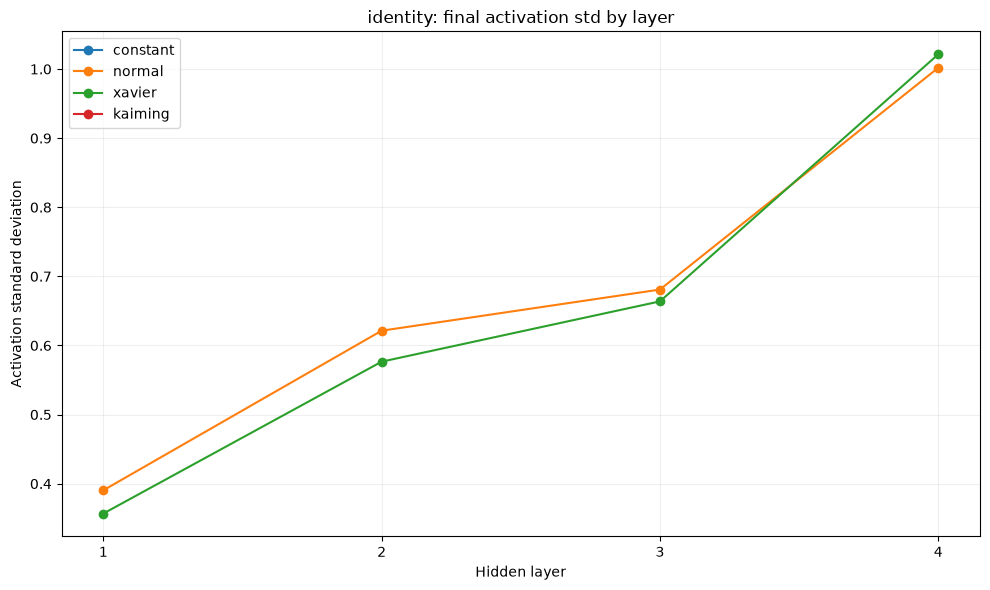

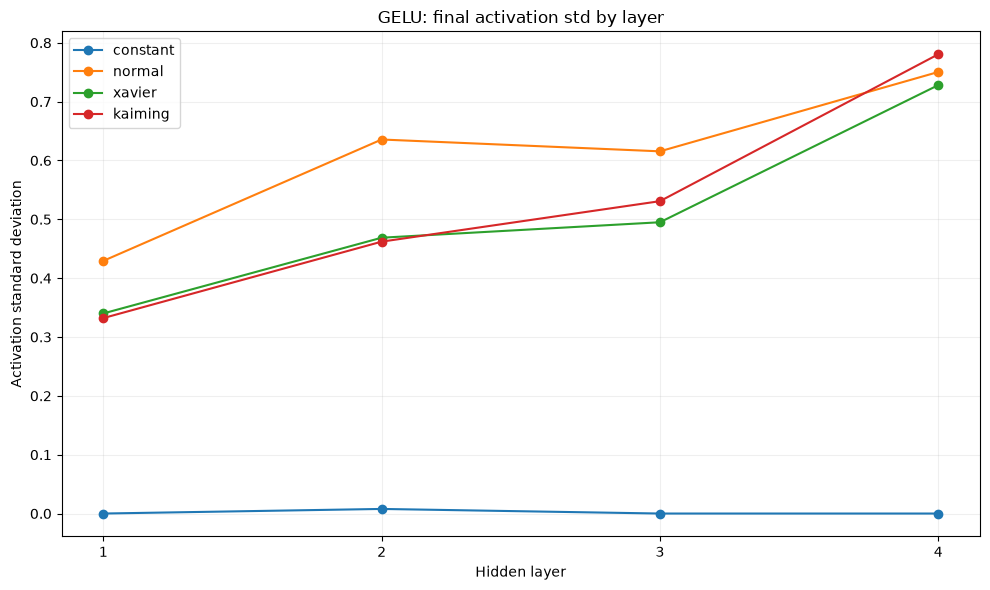

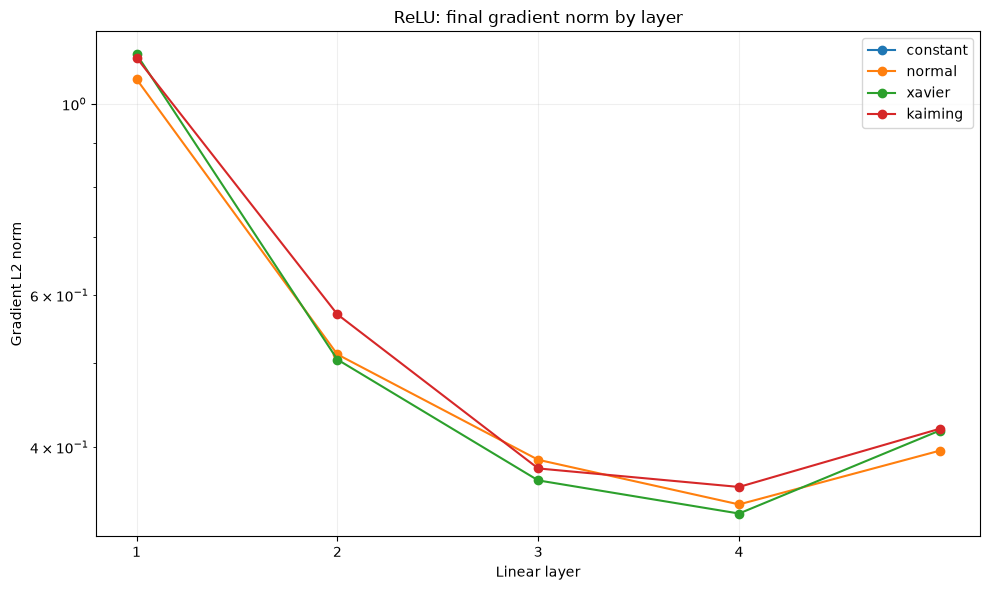

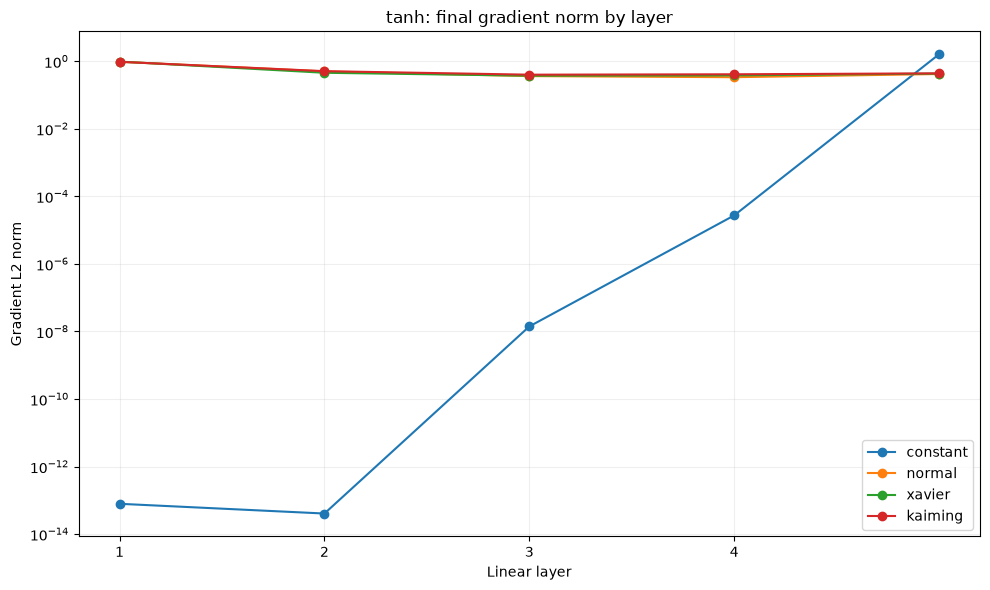

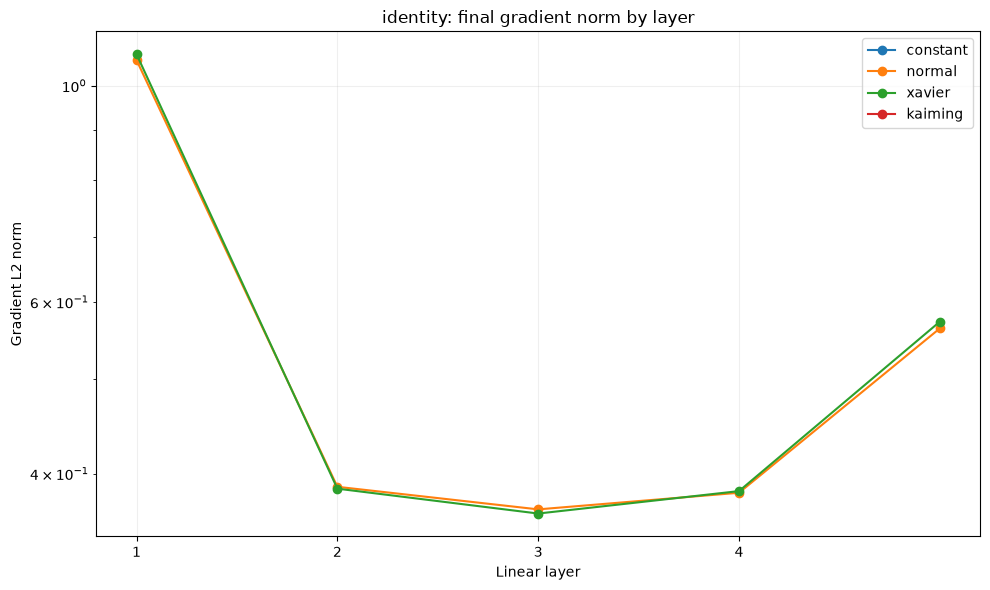

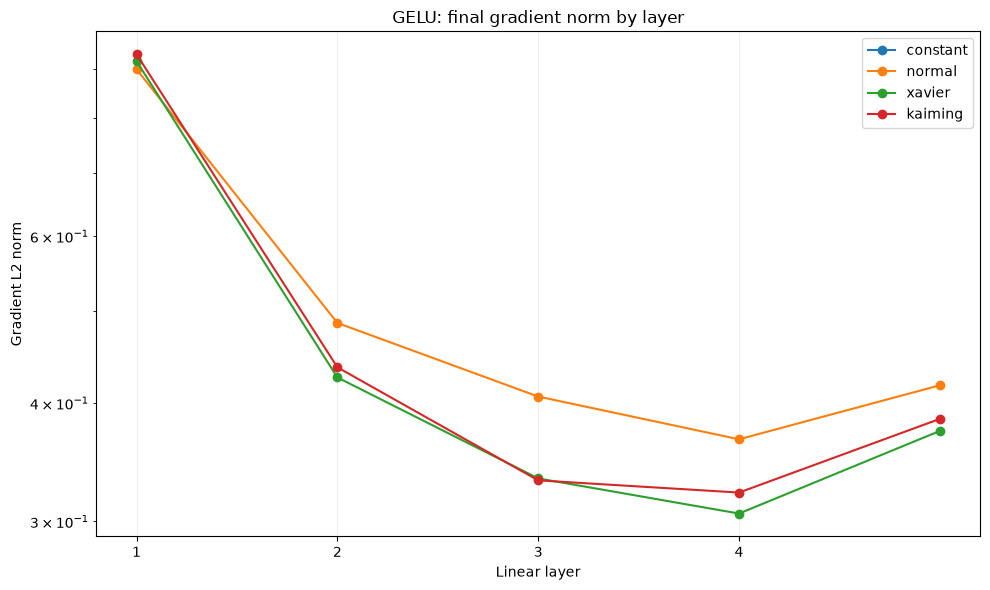

In [62]:
plot_final_layer_statistics(
    fashion_results
)

In [63]:
def safe_nanmean(values):
    values = np.asarray(values, dtype=float)
    finite_values = values[np.isfinite(values)]
    if len(finite_values) == 0:
        return np.nan
    return float(np.mean(finite_values))

def safe_nanmax(values):
    values = np.asarray(values, dtype=float)
    finite_values = values[np.isfinite(values)]
    if len(finite_values) == 0:
        return np.nan
    return float(np.max(finite_values))

def print_final_results(results):
    rows = []
    for (act_name, scheme), h in results.items():
        if h.get("diverged", False):
            rows.append({
                "Activation": act_name,
                "Initialization": scheme,
                "Train loss": np.nan,
                "Test loss": np.nan,
                "Test accuracy": np.nan,
                "Mean activation std": np.nan,
                "Max activation std": np.nan,
                "Mean gradient norm": np.nan,
                "Max gradient norm": np.nan,
                "Status": "DIVERGED",
            })
            continue
        train_loss = h["train_loss"][-1]
        test_loss = h["test_loss"][-1]
        test_accuracy = h["test_accuracy"][-1]
        activation_std = np.asarray(h["activation_std"][-1], dtype=float)
        gradient_norm = np.asarray(h["gradient_norm"][-1], dtype=float)
        rows.append({
            "Activation": act_name,
            "Initialization": scheme,
            "Train loss": train_loss,
            "Test loss": test_loss,
            "Test accuracy": test_accuracy,
            "Mean activation std": safe_nanmean(activation_std),
            "Max activation std": safe_nanmax(activation_std),
            "Mean gradient norm": safe_nanmean(gradient_norm),
            "Max gradient norm": safe_nanmax(gradient_norm),
            "Status": "OK",
        })
    rows = sorted(rows, key=lambda x: (x["Status"] != "OK", -np.nan_to_num(x["Test accuracy"], nan=-1)))
    print("\n" + "=" * 135)
    print(
        f"{'Activation':<12}"
        f"{'Init':<12}"
        f"{'Train loss':>12}"
        f"{'Test loss':>12}"
        f"{'Accuracy':>12}"
        f"{'Act std':>12}"
        f"{'Max act':>12}"
        f"{'Grad':>12}"
        f"{'Max grad':>12}"
        f"{'Status':>12}"
    )
    print("=" * 135)
    for row in rows:
        if row["Status"] == "DIVERGED":
            print(
                f"{row['Activation']:<12}"
                f"{row['Initialization']:<12}"
                f"{'—':>12}"
                f"{'—':>12}"
                f"{'—':>12}"
                f"{'—':>12}"
                f"{'—':>12}"
                f"{'—':>12}"
                f"{'—':>12}"
                f"{'DIVERGED':>12}"
            )
        else:
            print(
                f"{row['Activation']:<12}"
                f"{row['Initialization']:<12}"
                f"{row['Train loss']:>12.4f}"
                f"{row['Test loss']:>12.4f}"
                f"{row['Test accuracy'] * 100:>11.2f}%"
                f"{row['Mean activation std']:>12.4f}"
                f"{row['Max activation std']:>12.4f}"
                f"{row['Mean gradient norm']:>12.4f}"
                f"{row['Max gradient norm']:>12.4f}"
                f"{row['Status']:>12}"
            )
    print("=" * 135)

In [64]:
print_final_results(
    fashion_results
)


Activation  Init          Train loss   Test loss    Accuracy     Act std     Max act        Grad    Max grad      Status
ReLU        kaiming           0.3588      0.4379      84.44%      0.4887      0.7753      0.5717      1.1310          OK
ReLU        xavier            0.3791      0.4343      84.33%      0.3958      0.6278      0.5531      1.1413          OK
tanh        kaiming           0.3479      0.4441      84.04%      0.6352      0.7504      0.5439      0.9624          OK
GELU        kaiming           0.3615      0.4508      83.74%      0.5264      0.7805      0.4816      0.9335          OK
tanh        xavier            0.3783      0.4566      83.50%      0.5631      0.7111      0.5235      0.9765          OK
ReLU        normal            0.3796      0.4645      83.37%      0.4781      0.7142      0.5412      1.0681          OK
tanh        normal            0.3931      0.4733      83.11%      0.5494      0.6658      0.5168      0.9648          OK
GELU        xavier            0

## Задание 2. 

In [65]:
class Node:
    def __init__(self, data, _children=(), _op=""):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = tuple(_children)
        self._op = _op
    def __repr__(self):
        return f"Node(data={self.data:g}, grad={self.grad:g})"
    @staticmethod
    def _coerce(other):
        return other if isinstance(other, Node) else Node(other)
    def __add__(self, other):
        other = self._coerce(other)
        out = Node(self.data + other.data, (self, other), "+")
        def backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = backward
        return out
    __radd__ = __add__
    def __mul__(self, other):
        other = self._coerce(other)
        out = Node(self.data * other.data, (self, other), "*")
        def backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = backward
        return out
    __rmul__ = __mul__
    def relu(self):
        out = Node(max(0.0, self.data), (self,), "ReLU")
        def backward():
            if self.data > 0:
                self.grad += out.grad
        out._backward = backward
        return out
    def backward(self):
        topo = []
        visited = set()
        def build_topological_order(node):
            if node not in visited:
                visited.add(node)
                for parent in node._prev:
                    build_topological_order(parent)
                topo.append(node)
        build_topological_order(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [66]:
import unittest

class HomeworkTests(unittest.TestCase):
    def test_node_example(self):
        a, b, c = Node(2), Node(-3), Node(10)
        d = a + b * c
        e = d.relu()
        e.backward()
        self.assertEqual((a.grad, b.grad, c.grad, d.grad, e.grad), (0, 0, 0, 0, 1))
    def test_node_positive_and_shared_paths(self):
        x = Node(3)
        y = x * x + 2 * x
        y.backward()
        self.assertAlmostEqual(y.data, 15)
        self.assertAlmostEqual(x.grad, 8)
    def test_relu_positive(self):
        x = Node(3)
        y = x.relu()
        y.backward()
        self.assertEqual(y.data, 3)
        self.assertEqual(x.grad, 1)
    def test_relu_negative(self):
        x = Node(-3)
        y = x.relu()
        y.backward()
        self.assertEqual(y.data, 0)
        self.assertEqual(x.grad, 0)
    def test_addition(self):
        x = Node(2)
        y = Node(5)
        z = x + y
        z.backward()
        self.assertEqual(z.data, 7)
        self.assertEqual(x.grad, 1)
        self.assertEqual(y.grad, 1)
    def test_multiplication(self):
        x = Node(2)
        y = Node(5)
        z = x * y
        z.backward()
        self.assertEqual(z.data, 10)
        self.assertEqual(x.grad, 5)
        self.assertEqual(y.grad, 2)
    def test_scalar_operations(self):
        x = Node(3)
        y = 2 * x + 1
        y.backward()
        self.assertEqual(y.data, 7)
        self.assertEqual(x.grad, 2)

suite = unittest.defaultTestLoader.loadTestsFromTestCase(HomeworkTests)
test_result = unittest.TextTestRunner(verbosity=2).run(suite)
assert test_result.wasSuccessful()

test_addition (__main__.HomeworkTests.test_addition) ... ok
test_multiplication (__main__.HomeworkTests.test_multiplication) ... ok
test_node_example (__main__.HomeworkTests.test_node_example) ... ok
test_node_positive_and_shared_paths (__main__.HomeworkTests.test_node_positive_and_shared_paths) ... ok
test_relu_negative (__main__.HomeworkTests.test_relu_negative) ... ok
test_relu_positive (__main__.HomeworkTests.test_relu_positive) ... ok
test_scalar_operations (__main__.HomeworkTests.test_scalar_operations) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.008s

OK


## Задание 3. 

In [67]:
class Adam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
    @torch.no_grad()
    def step(self):
        self.t += 1
        for p, m, v in zip(self.params, self.m, self.v):
            if p.grad is None:
                continue
            g = p.grad
            if self.weight_decay != 0:
                g = g.add(p, alpha=self.weight_decay)
            m.mul_(self.beta1)
            m.add_(g, alpha=1 - self.beta1)
            v.mul_(self.beta2)
            v.addcmul_(g, g, value=1 - self.beta2)
            m_hat = m / (1 - self.beta1 ** self.t)
            v_hat = v / (1 - self.beta2 ** self.t)
            p.addcdiv_(m_hat, v_hat.sqrt().add(self.eps), value=-self.lr)
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad = None

In [68]:
class AdamTests(unittest.TestCase):
    def test_adam_one_dimensional_step(self):
        p = torch.nn.Parameter(torch.tensor([1.0]))
        opt = Adam([p], lr=0.1)
        p.grad = torch.tensor([2.0])
        opt.step()
        self.assertAlmostEqual(p.item(), 0.9, places=5)
    def test_adam_zero_grad(self):
        p = torch.nn.Parameter(torch.tensor([1.0]))
        opt = Adam([p], lr=0.1)
        p.grad = torch.tensor([2.0])
        opt.zero_grad()
        self.assertIsNone(p.grad)
    def test_adam_multiple_steps(self):
        p = torch.nn.Parameter(torch.tensor([1.0]))
        opt = Adam([p], lr=0.1)
        for _ in range(10):
            p.grad = torch.tensor([1.0])
            opt.step()
        self.assertLess(p.item(), 1.0)
    def test_adam_skips_none_grad(self):
        p1 = torch.nn.Parameter(torch.tensor([1.0]))
        p2 = torch.nn.Parameter(torch.tensor([2.0]))
        opt = Adam([p1, p2], lr=0.1)
        p1.grad = torch.tensor([1.0])
        p2.grad = None
        opt.step()
        self.assertAlmostEqual(p1.item(), 0.9, places=5)
        self.assertAlmostEqual(p2.item(), 2.0, places=5)

suite = unittest.defaultTestLoader.loadTestsFromTestCase(AdamTests)
test_result = unittest.TextTestRunner(verbosity=2).run(suite)
assert test_result.wasSuccessful()

test_adam_multiple_steps (__main__.AdamTests.test_adam_multiple_steps) ... ok
test_adam_one_dimensional_step (__main__.AdamTests.test_adam_one_dimensional_step) ... ok
test_adam_skips_none_grad (__main__.AdamTests.test_adam_skips_none_grad) ... ok
test_adam_zero_grad (__main__.AdamTests.test_adam_zero_grad) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.012s

OK


In [69]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

class FashionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(x)

model = FashionModel()
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

num_epochs = 5
train_losses = []
test_accuracies = []
gradient_norms = []
weight_distributions = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    total = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        total_grad_norm = 0.0
        for parameter in model.parameters():
            if parameter.grad is not None:
                total_grad_norm += parameter.grad.detach().norm().item() ** 2
        total_grad_norm = total_grad_norm ** 0.5
        gradient_norms.append(total_grad_norm)
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)
        total += images.size(0)
    epoch_loss /= total
    train_losses.append(epoch_loss)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    test_accuracies.append(accuracy)
    weights = []
    for parameter in model.parameters():
        weights.extend(parameter.detach().cpu().flatten().tolist())
    weight_distributions.append(weights)
    print(f"Epoch {epoch + 1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {accuracy:.4f}")

Epoch 1/5 | Loss: 0.6133 | Accuracy: 0.8301
Epoch 2/5 | Loss: 0.4070 | Accuracy: 0.8557
Epoch 3/5 | Loss: 0.3700 | Accuracy: 0.8576
Epoch 4/5 | Loss: 0.3412 | Accuracy: 0.8686
Epoch 5/5 | Loss: 0.3195 | Accuracy: 0.8613


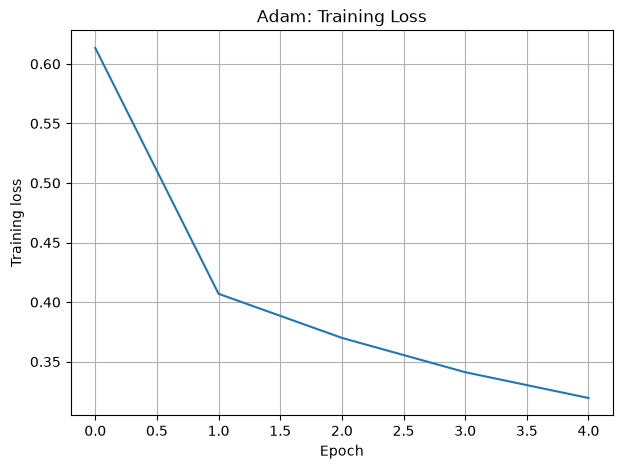

In [70]:
plt.figure(figsize=(7, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Adam: Training Loss")

plt.grid()
plt.show()

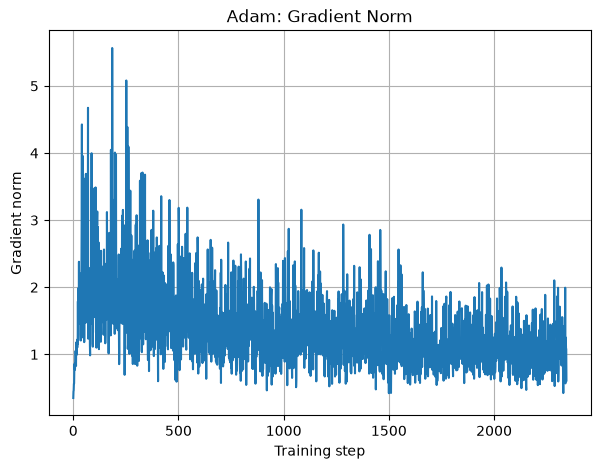

In [71]:
plt.figure(figsize=(7, 5))

plt.plot(gradient_norms)

plt.xlabel("Training step")
plt.ylabel("Gradient norm")
plt.title("Adam: Gradient Norm")

plt.grid()
plt.show()

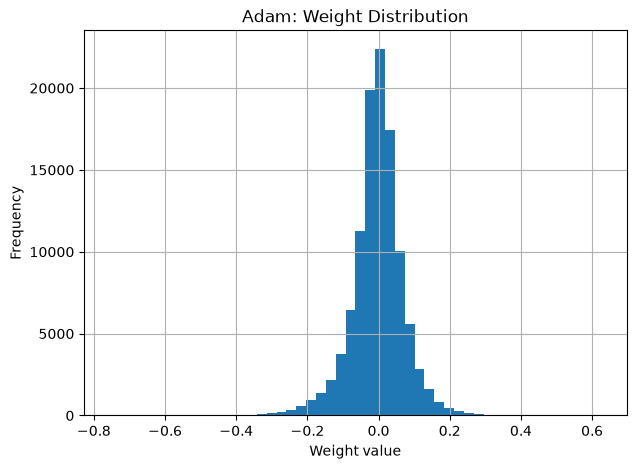

In [72]:
plt.figure(figsize=(7, 5))

plt.hist(
    weight_distributions[-1],
    bins=50
)

plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.title("Adam: Weight Distribution")

plt.grid()
plt.show()

## Задание 4.

In [ ]:
YEAR_MIN = 1922
YEAR_MAX = 2011


def find_id_columns(df):
    preferred_names = {"index", "id", "example_id", "unnamed: 0"}
    preferred = [
        col for col in df.columns
        if str(col).strip().lower() in preferred_names
    ]

    candidates = []
    for col in df.columns:
        values = pd.to_numeric(df[col], errors="coerce")
        if (
            values.notna().all()
            and values.is_unique
            and np.allclose(values.to_numpy(), np.round(values.to_numpy()))
        ):
            candidates.append(col)

    named_candidates = [col for col in preferred if col in candidates]
    return named_candidates if named_candidates else candidates


class SongRegressor(nn.Module):

    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.10),

            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def run_song_task(
    data_dir,
    epochs=100,
    batch_size=512,
    patience=12,
    custom_optimizer=True,
):
    """Обучает MLP, печатает validation-метрики и сохраняет целые годы."""
    root = Path(data_dir)
    torch.manual_seed(42)

    train_x_raw = pd.read_csv(root / "train_x.csv")
    train_y_raw = pd.read_csv(root / "train_y.csv")
    test_x_raw = pd.read_csv(root / "test_x.csv")

    train_id_col = train_x_raw.columns[0]
    target_id_col = train_y_raw.columns[0]

    test_id_candidates = find_id_columns(test_x_raw)
    if len(test_id_candidates) != 1:
        raise ValueError(
            "Не удалось однозначно определить ID-столбец в test_x.csv. "
            f"Кандидаты: {test_id_candidates}. "
            "Проверьте столбцы test_x_raw и задайте test_id_col вручную."
        )
    test_id_col = test_id_candidates[0]

    target_col = "year" if "year" in train_y_raw.columns else train_y_raw.columns[-1]

    train_ids = train_x_raw[train_id_col]
    target_ids = train_y_raw[target_id_col]
    test_ids = test_x_raw[test_id_col].to_numpy()

    if train_ids.duplicated().any():
        raise ValueError("В train_x.csv найдены повторяющиеся ID.")
    if target_ids.duplicated().any():
        raise ValueError("В train_y.csv найдены повторяющиеся ID.")
    if pd.Series(test_ids).duplicated().any():
        raise ValueError("В test_x.csv найдены повторяющиеся ID.")

    train_x = train_x_raw.rename(columns={train_id_col: "_id"})
    train_y = train_y_raw.rename(columns={target_id_col: "_id"})
    train = train_x.merge(
        train_y[["_id", target_col]],
        on="_id",
        how="inner",
        validate="one_to_one",
    )

    if len(train) != len(train_x_raw):
        raise ValueError(
            f"После соединения train_x и train_y осталось {len(train)} строк "
            f"из {len(train_x_raw)}. Проверьте соответствие ID."
        )

    feature_cols = [
        col for col in train_x_raw.columns
        if col != train_id_col
    ]
    test_feature_cols = [
        col for col in test_x_raw.columns
        if col != test_id_col
    ]

    if len(feature_cols) != 90 or len(test_feature_cols) != 90:
        raise ValueError(
            "После исключения ID должно остаться по 90 признаков. "
            f"Получено: train={len(feature_cols)}, test={len(test_feature_cols)}. "
            f"ID test: {test_id_col!r}"
        )

    x_df = train[feature_cols].apply(pd.to_numeric, errors="coerce")
    xt_df = test_x_raw[test_feature_cols].copy()
    xt_df.columns = feature_cols
    xt_df = xt_df.apply(pd.to_numeric, errors="coerce")

    x_df = x_df.replace([np.inf, -np.inf], np.nan)
    xt_df = xt_df.replace([np.inf, -np.inf], np.nan)
    medians = x_df.median()
    x_df = x_df.fillna(medians).fillna(0)
    xt_df = xt_df.fillna(medians).fillna(0)

    x = x_df.to_numpy(dtype=np.float32)
    xt = xt_df.to_numpy(dtype=np.float32)
    y = train[target_col].to_numpy(dtype=np.float32)

    print(f"Train ID: {train_id_col!r}; target ID: {target_id_col!r}")
    print(f"Test ID: {test_id_col!r}")
    print(f"Число признаков: {x.shape[1]}")
    print(f"Годы в train: {y.min():.0f}–{y.max():.0f}")

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=0.15,
        random_state=42,
    )

    x_mean = x_train.mean(axis=0, keepdims=True)
    x_std = x_train.std(axis=0, keepdims=True)
    x_std[x_std < 1e-6] = 1.0

    y_mean = float(y_train.mean())
    y_std = max(float(y_train.std()), 1e-6)

    def scale_x(values):
        return ((values - x_mean) / x_std).astype(np.float32)

    def scale_y(values):
        return ((values - y_mean) / y_std).astype(np.float32)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tx = torch.from_numpy(scale_x(x_train)).to(device)
    ty = torch.from_numpy(scale_y(y_train)).to(device)
    vx = torch.from_numpy(scale_x(x_val)).to(device)

    model = SongRegressor(input_size=x.shape[1]).to(device)

    if custom_optimizer:
        optimizer = Adam(
            model.parameters(),
            lr=8e-4,
            weight_decay=1e-5,
        )
        optimizer_name = "самописный Adam"
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=8e-4,
            weight_decay=1e-4,
        )
        optimizer_name = "torch AdamW"

    best_state = None
    best_mse = float("inf")
    best_metrics = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        order = torch.randperm(tx.shape[0], device=device)
        batch_losses = []
        grad_norms = []

        for indices in order.split(batch_size):
            if indices.numel() < 2:
                continue

            optimizer.zero_grad()
            predictions = model(tx[indices])
            loss = nn.functional.smooth_l1_loss(predictions, ty[indices])
            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )
            grad_norms.append(float(grad_norm.item()))

            optimizer.step()
            batch_losses.append(float(loss.item()))

        model.eval()
        with torch.no_grad():
            val_pred_scaled = model(vx).cpu().numpy()

        val_predictions = val_pred_scaled * y_std + y_mean
        val_predictions = np.clip(val_predictions, YEAR_MIN, YEAR_MAX)
        val_predictions_int = np.floor(val_predictions + 0.5).astype(np.int64)

        val_mae = float(np.mean(np.abs(val_predictions_int - y_val)))
        val_mse = float(np.mean((val_predictions_int - y_val) ** 2))
        val_rmse = float(np.sqrt(val_mse))

        mean_grad_norm = float(np.mean(grad_norms)) if grad_norms else 0.0
        mean_train_loss = (
            float(np.mean(batch_losses)) if batch_losses else float("nan")
        )

        weight_tensors = [
            parameter.detach().flatten()
            for parameter in model.parameters()
            if parameter.ndim > 1
        ]
        weight_std = torch.cat(weight_tensors).std().item()

        print(
            f"epoch {epoch + 1:03d} "
            f"train_smoothL1={mean_train_loss:.4f} "
            f"val_MAE={val_mae:.4f} "
            f"val_MSE={val_mse:.4f} "
            f"val_RMSE={val_rmse:.4f} "
            f"grad_norm={mean_grad_norm:.3f} "
            f"weight_std={weight_std:.4f}"
        )

        if val_mse < best_mse:
            best_mse = val_mse
            best_metrics = {
                "validation_mae": val_mae,
                "validation_mse": val_mse,
                "validation_rmse": val_rmse,
            }
            epochs_without_improvement = 0
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping.")
                break

    if best_state is None:
        raise RuntimeError("Обучение не сохранило ни одного чекпойнта.")

    model.load_state_dict(best_state)
    model.eval()

    test_tensor = torch.from_numpy(scale_x(xt)).to(device)
    with torch.no_grad():
        test_predictions_scaled = model(test_tensor).cpu().numpy()

    test_predictions = test_predictions_scaled * y_std + y_mean
    test_predictions = np.clip(test_predictions, YEAR_MIN, YEAR_MAX)
    test_predictions = np.floor(test_predictions + 0.5).astype(np.int64)

    submission = pd.DataFrame({
        "id": test_ids,
        "year": test_predictions,
    })

    suffix = "custom_adam" if custom_optimizer else "torch_adamw"
    output_path = root / f"submission_{suffix}.csv"
    submission.to_csv(output_path, index=False)

    print(f"\nОптимизатор: {optimizer_name}")
    print(f"Validation MAE:  {best_metrics['validation_mae']:.4f} года")
    print(f"Validation MSE:  {best_metrics['validation_mse']:.4f}")
    print(f"Validation RMSE: {best_metrics['validation_rmse']:.4f} года")
    print(f"Submission сохранён: {output_path}")
    print("Первые строки submission:")
    print(submission.head())

    return model, {
        **best_metrics,
        "submission": output_path,
    }


def compare_song_optimizers(data_dir, epochs=100, batch_size=512):
    _, custom_result = run_song_task(
        data_dir=data_dir,
        epochs=epochs,
        batch_size=batch_size,
        custom_optimizer=True,
    )

    _, torch_result = run_song_task(
        data_dir=data_dir,
        epochs=epochs,
        batch_size=batch_size,
        custom_optimizer=False,
    )

    print("\nСравнение оптимизаторов по validation MSE:")
    print(
        f"Самописный Adam: {custom_result['validation_mse']:.4f} "
        f"(MAE={custom_result['validation_mae']:.4f}, "
        f"RMSE={custom_result['validation_rmse']:.4f})"
    )
    print(
        f"torch AdamW:     {torch_result['validation_mse']:.4f} "
        f"(MAE={torch_result['validation_mae']:.4f}, "
        f"RMSE={torch_result['validation_rmse']:.4f})"
    )

    return {
        "custom_adam": custom_result,
        "torch_adamw": torch_result,
    }

In [ ]:
DATA_DIR = Path(r"C:\Users\2005k\spbu_dl_2026\homeworks\data_hw1")

required_files = ["train_x.csv", "train_y.csv", "test_x.csv"]
missing = [name for name in required_files if not (DATA_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"В {DATA_DIR} отсутствуют файлы: {missing}")

train_x_check = pd.read_csv(DATA_DIR / "train_x.csv")
train_y_check = pd.read_csv(DATA_DIR / "train_y.csv")
test_x_check = pd.read_csv(DATA_DIR / "test_x.csv")

train_id_col = train_x_check.columns[0]
target_id_col = train_y_check.columns[0]

def integer_unique_columns(df):
    candidates = []
    for col in df.columns:
        values = pd.to_numeric(df[col], errors="coerce")
        if (
            values.notna().all()
            and values.is_unique
            and np.allclose(values.to_numpy(), np.round(values.to_numpy()))
        ):
            candidates.append(col)
    return candidates

test_id_candidates = integer_unique_columns(test_x_check)

print("train_x ID:", train_id_col)
print("train_y ID:", target_id_col)
print("train_x ID unique:", train_x_check[train_id_col].is_unique)
print("train_y ID unique:", train_y_check[target_id_col].is_unique)
print("test_x ID candidates:", test_id_candidates)

if len(test_id_candidates) == 1:
    detected_test_id_col = test_id_candidates[0]
    print("test_x ID:", detected_test_id_col)
    print("Первые test ID:", test_x_check[detected_test_id_col].head().tolist())
else:
    raise ValueError(
        "В test_x не найден однозначный целочисленный ID. "
        f"Проверьте кандидатов: {test_id_candidates}"
    )

song_results = compare_song_optimizers(
    data_dir=str(DATA_DIR),
    epochs=100,
    batch_size=512,
)

train_x ID: Unnamed: 0
train_y ID: Unnamed: 0
train_x ID unique: True
train_y ID unique: True
test_x ID candidates: ['id']
test_x ID: id
Первые test ID: [3416, 18991, 11105, 18902, 18958]
Train ID: 'Unnamed: 0'; target ID: 'Unnamed: 0'
Test ID: 'id'
Число признаков: 90
Годы в train: 1922–2011
epoch 001 train_smoothL1=0.3288 val_MAE=6.8224 val_MSE=95.3519 val_RMSE=9.7648 grad_norm=0.206 weight_std=0.0487
epoch 002 train_smoothL1=0.2799 val_MAE=6.2076 val_MSE=86.2124 val_RMSE=9.2851 grad_norm=0.187 weight_std=0.0489
epoch 003 train_smoothL1=0.2625 val_MAE=6.0414 val_MSE=83.9624 val_RMSE=9.1631 grad_norm=0.206 weight_std=0.0491
epoch 004 train_smoothL1=0.2564 val_MAE=6.0771 val_MSE=83.5581 val_RMSE=9.1410 grad_norm=0.226 weight_std=0.0493
epoch 005 train_smoothL1=0.2436 val_MAE=5.9990 val_MSE=82.8095 val_RMSE=9.1000 grad_norm=0.219 weight_std=0.0495
epoch 006 train_smoothL1=0.2335 val_MAE=6.0181 val_MSE=82.4505 val_RMSE=9.0802 grad_norm=0.225 weight_std=0.0497
epoch 007 train_smoothL1=0.2